In [ ]:
import os
import cv2
import csv
import numpy as np
import pandas as pd
from time import time
from tensorflow.keras import utils
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.applications import VGG19
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
for i in range (0,43):
    path, dirs, files = next(os.walk(f"/content/drive/MyDrive/Project/Train/{i}"))
    file_count = len(files)
    print(f"Files for class {i}: {file_count}")

Files for class 0: 210
Files for class 1: 2220
Files for class 2: 2250
Files for class 3: 1410
Files for class 4: 1980
Files for class 5: 1860
Files for class 6: 420
Files for class 7: 1440
Files for class 8: 1410
Files for class 9: 1470
Files for class 10: 2010
Files for class 11: 1320
Files for class 12: 2100
Files for class 13: 2160
Files for class 14: 780
Files for class 15: 630
Files for class 16: 420
Files for class 17: 1110
Files for class 18: 1200
Files for class 19: 210
Files for class 20: 360
Files for class 21: 330
Files for class 22: 390
Files for class 23: 510
Files for class 24: 270
Files for class 25: 1500
Files for class 26: 600
Files for class 27: 240
Files for class 28: 540
Files for class 29: 270
Files for class 30: 450
Files for class 31: 780
Files for class 32: 240
Files for class 33: 689
Files for class 34: 420
Files for class 35: 1200
Files for class 36: 390
Files for class 37: 210
Files for class 38: 2070
Files for class 39: 300
Files for class 40: 360
Files for

In [ ]:
import os
import csv
import cv2
import numpy as np

def preprocess(image, out_side):
    height, width = image.shape[:2]
    scale = out_side / max(height, width)
    dx = (out_side - scale * width) / 2
    dy = (out_side - scale * height) / 2
    trans = np.array([[scale, 0, dx], [0, scale, dy]], dtype=np.float32)
    image = cv2.warpAffine(image, trans, (out_side, out_side), flags=cv2.INTER_AREA)
    return image  # No need to resize again here

def mixing(images, labels):
    images = np.array(images)
    labels = np.array(labels)
    s = np.arange(images.shape[0])
    np.random.seed(43)
    np.random.shuffle(s)
    images = images[s]
    labels = labels[s]
    return images, labels

def load_train(path, out_side):
    images = []
    labels = []
    train_path = os.path.join(path, 'Train')

    for folder in os.listdir(train_path):
        cur_path = os.path.join(train_path, folder)
        for file_name in os.listdir(cur_path):
            image_path = os.path.join(cur_path, file_name)
            if not os.path.exists(image_path):
                print(f"File not found: {image_path}. Skipping.")
                continue  # Skip if the file does not exist

            image = cv2.imread(image_path)
            if image is None:
                print(f"Error loading image: {image_path}. Skipping.")
                continue  # Skip if image cannot be loaded

            images.append(preprocess(image, out_side))
            labels.append(int(folder))  # Assuming folder name is the label

    return mixing(images, labels)

def load_test(path, out_side):
    images = []
    labels = []
    csv_file_path = os.path.join(path, 'Test.csv')

    with open(csv_file_path, 'r') as f:
        reader = csv.reader(f)
        # Skip the header row
        header = next(reader)

        for rows in reader:
            name = rows[7]  # Adjust index based on your CSV structure
            if name == 'Path':  # Skip the header or placeholder
                continue

            image_path = os.path.join(path+"Test", name)
            if not os.path.exists(image_path):
                print(f"File not found: {image_path}. Stopping processing.")
                break  # Stop processing if the file does not exist

            image = cv2.imread(image_path)
            if image is None:
                print(f"Error loading image: {image_path}. Skipping.")
                continue  # Skip if image cannot be loaded

            images.append(preprocess(image, out_side))
            labels.append(int(rows[6]))  # Assuming the label is in the 7th column

    return mixing(images, labels)

In [ ]:
dir = "/content/drive/MyDrive/Project"
start = time()

train_images, train_labels = load_train(dir + "/", 50)
test_images, test_labels = load_test(dir+ "/", 50)
shape1 = train_images[0].shape
print(shape1)
shape2 = test_images[0].shape
print(shape2)

train_images = train_images.astype('float32') / 255.
test_images = test_images.astype('float32') / 255.

train_labels = utils.to_categorical(train_labels, 43)
test_labels = utils.to_categorical(test_labels, 43)

print('Loading: ', time() - start)


File not found: /content/drive/MyDrive/Project/Test/Test/02788.png. Stopping processing.
(50, 50, 3)
(50, 50, 3)
Loading:  3398.2235066890717


In [ ]:
train_image_data = pd.read_csv('/content/drive/MyDrive/Project/Train.csv')
test_image_data = pd.read_csv('/content/drive/MyDrive/Project/Test.csv')

In [ ]:
train_image_data.describe()
test_image_data.describe()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId
count,12630.000000,12630.000000,12630.000000,12630.000000,12630.000000,12630.000000,12630.000000
mean,50.507759,50.364450,5.998021,5.982423,44.864450,44.758116,15.551069
std,25.088483,23.698908,1.543954,1.427424,23.776102,22.494697,11.947123
min,25.000000,25.000000,1.000000,5.000000,20.000000,20.000000,0.000000
25%,34.000000,35.000000,5.000000,5.000000,29.000000,29.000000,5.000000
50%,43.000000,43.000000,6.000000,6.000000,38.000000,38.000000,12.000000
75%,58.000000,57.000000,6.000000,6.000000,53.000000,52.000000,25.000000
max,266.000000,232.000000,23.000000,19.000000,244.000000,212.000000,42.000000


In [ ]:
classes = 43
batch = 256
epochs = 15
learning_rate = 0.0001

def results(model, model_name):
  adam = Adam(learning_rate=learning_rate)

  model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

  start = time()
  history = model.fit(train_images, train_labels, batch_size=batch, epochs=epochs, validation_split=0.2, shuffle = True, verbose=1)
  train_time = time() - start

  model.summary()

  plt.figure(figsize=(12, 12))
  plt.subplot(3, 2, 1)
  plt.plot(history.history['accuracy'], label = 'train_accuracy')
  plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
  plt.xlabel('epoch')
  plt.ylabel('accuracy')
  plt.legend()
  plt.subplot(3, 2, 2)
  plt.plot(history.history['loss'], label = 'train_loss')
  plt.plot(history.history['val_loss'], label = 'val_loss')
  plt.xlabel('epoch')
  plt.ylabel('accuracy')
  plt.legend()
  plt.show()

  start = time()
  test_loss, test_acc = model.evaluate(test_images, test_labels)
  test_time = time() - start
  print('\nTrain time: ', train_time)
  print('Test accuracy:', test_acc)
  print('Test loss:', test_loss)
  print('Test time: ', test_time)

  # Save metrics to a CSV file
  save_metrics_csv(model_name, test_acc, test_loss,history)

  # Saving model
  model.save(r'/content/drive/MyDrive/Project/vgg19_model_RTSR.h5')

def save_metrics_csv(model_name, test_acc, test_loss,history, filename='/content/drive/MyDrive/Project/model_accuracies_cleaned.csv'):
    file_exists = os.path.isfile(filename)
    with open(filename, mode='a', newline='') as file:
        writer = csv.writer(file)
        if not file_exists:
            # Write header if file does not exist
            writer.writerow(['Model', 'Test Accuracy', 'Test Loss'])
        writer.writerow([model_name, history.history['val_accuracy'][-1], history.history['val_loss'][-1]])

Epoch 1/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.5993 - loss: 1.5665 - val_accuracy: 0.9728 - val_loss: 1.0539
Epoch 2/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9908 - loss: 0.0401 - val_accuracy: 0.9962 - val_loss: 0.2168
Epoch 3/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9980 - loss: 0.0096 - val_accuracy: 0.9906 - val_loss: 0.0418
Epoch 4/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9976 - loss: 0.0082 - val_accuracy: 0.9925 - val_loss: 0.0298
Epoch 5/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9980 - loss: 0.0075 - val_accuracy: 0.9968 - val_loss: 0.0134
Epoch 6/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9978 - loss: 0.0090 - val_accuracy: 0.9957 - val_loss: 0.0184
Epoch 7/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9972 - loss: 0.0102 - val_accuracy: 0.9857 - val_loss: 0.0592
Epoch 8/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9973 - loss: 0.0103 - val_acc

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)                   │ (None, 1, 1, 512)           │      20,024,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 1, 1, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1024)                │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 43)                  │          44,075 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61,785,411 (235.69 MB)

 Trainable params: 20,594,795 (78.56 MB)

 Non-trainable params: 1,024 (4.00 KB)

 Optimizer params: 41,189,592 (157.13 MB)

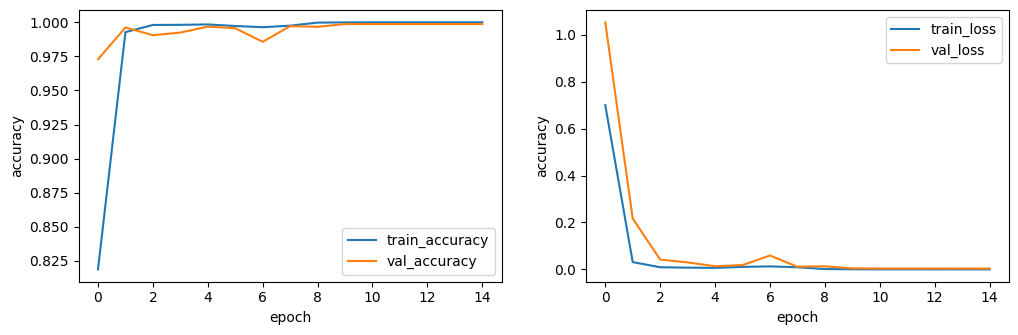

88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9811 - loss: 0.0716



Train time:  72.47169876098633
Test accuracy: 0.9788378477096558
Test loss: 0.07853852212429047
Test time:  1.8116683959960938


In [ ]:
model = Sequential()
model.add(VGG19(weights='imagenet', include_top=False, input_shape=(50,50,3)))
model.add(BatchNormalization())
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dense(43, activation='softmax'))

results(model, model_name = 'VGG19')

In [ ]:
print(train_images.shape)
print(test_images.shape)

(39209, 50, 50, 3)
(2788, 50, 50, 3)


In [ ]:
model

<Sequential name=sequential, built=True>